In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from abstract_values.behavior.data import Subject, get_all_subjects, get_all_subject_ids, get_all_behavioral_data

In [2]:
df = get_all_behavioral_data()
df = df[df['event_type'] == 'feedback']

df['response'] = df['response'].astype(float)

In [20]:
# Count non-responses per subject (normalized)
non_responses = df[df['response'].isna()].groupby('subject').size() / df.groupby('subject').size()
print("Non-responses per subject:")
print(non_responses)

non_responses.agg(['mean', 'std'])

Non-responses per subject:
subject
1     0.046196
2     0.021739
3     0.013587
4     0.016304
5     0.046196
7     0.010870
8     0.016304
9     0.032609
10    0.046196
11    0.016304
12    0.032609
13    0.021739
dtype: float64


mean    0.026721
std     0.013504
dtype: float64

In [26]:
df.groupby(['subject', 'mapping']).size()

subject  mapping    
1        cdf            184
         inverse_cdf    184
2        cdf            184
         inverse_cdf    184
3        cdf            184
         inverse_cdf    184
4        cdf            184
         inverse_cdf    184
5        cdf            184
         inverse_cdf    184
7        cdf            184
         inverse_cdf    184
8        cdf            184
9        inverse_cdf    184
10       cdf            184
         inverse_cdf    184
11       inverse_cdf    184
12       cdf            184
13       inverse_cdf    184
dtype: int64

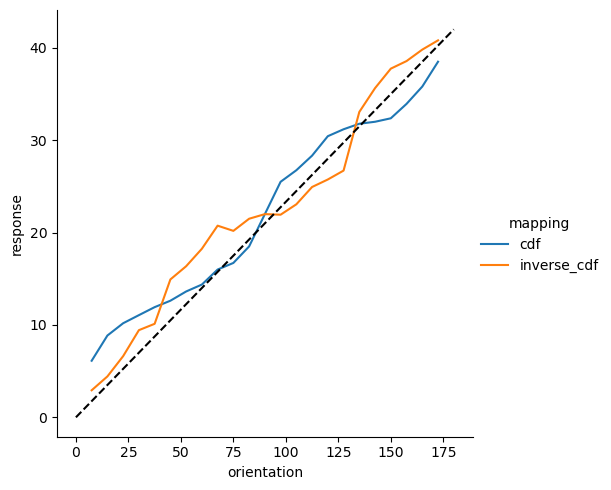

In [27]:
tmp = df.xs(5, level='subject', drop_level=False).groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')

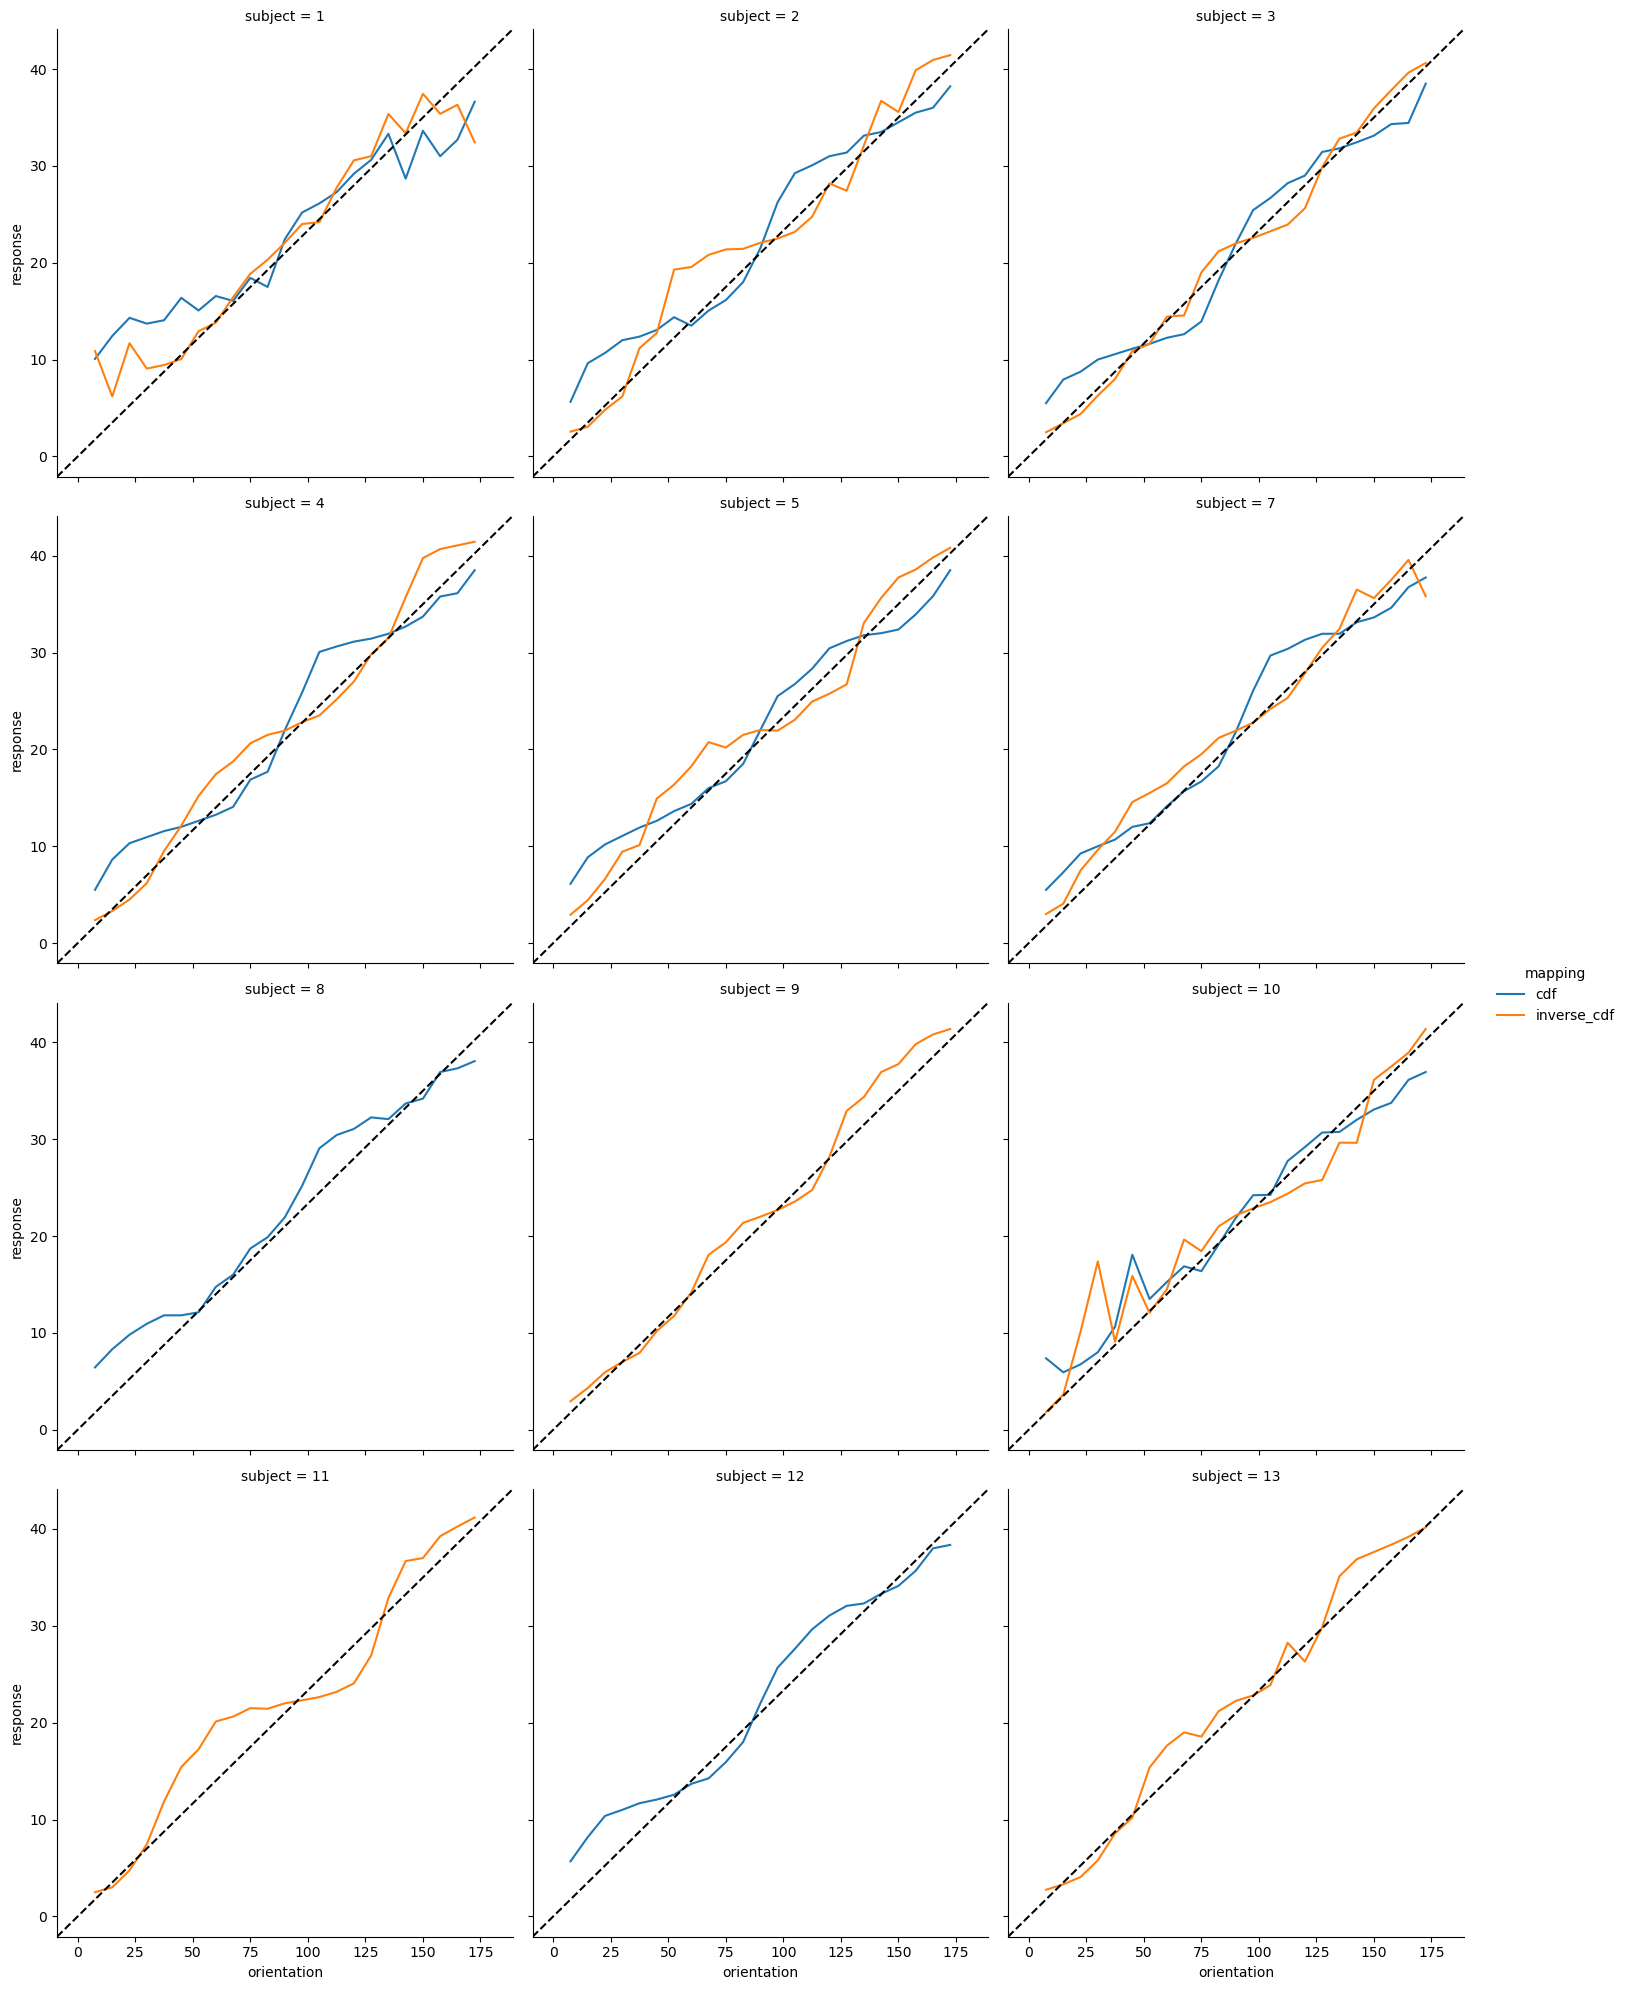

In [11]:
tmp = df.groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line',
                col='subject', col_wrap=3)

g.map(plt.axline, xy1=(0, 0), xy2=(180, 42), ls='--', c='k')

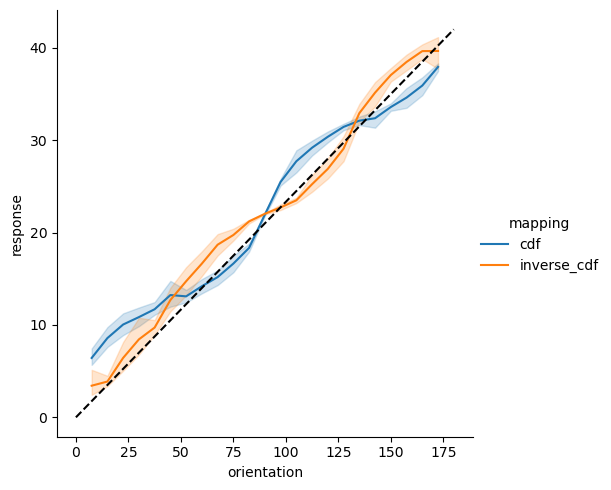

In [28]:
tmp = df.groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')

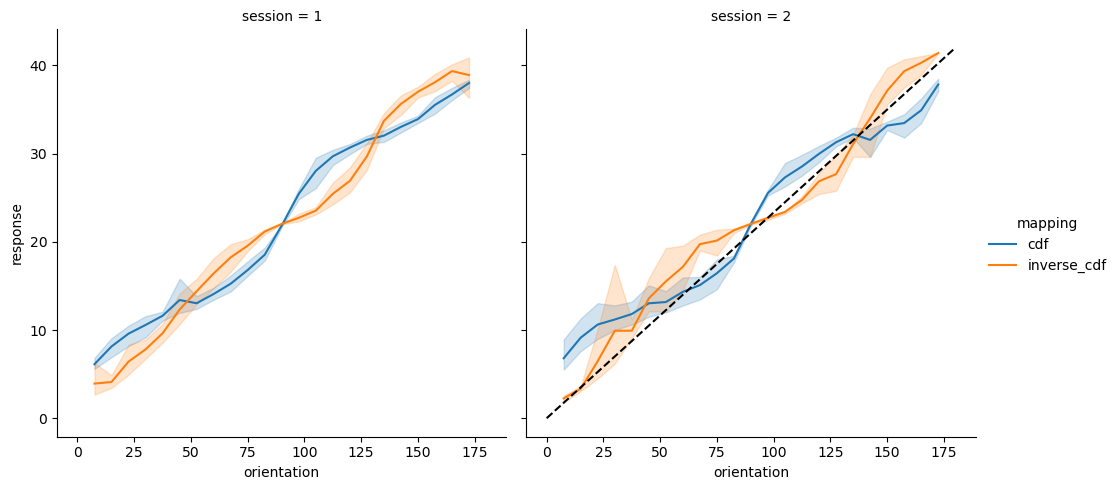

In [39]:
tmp = df.groupby(['subject', 'mapping', 'orientation', 'session'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line', col='session')
plt.plot([0, 180], [0, 42], 'k--')

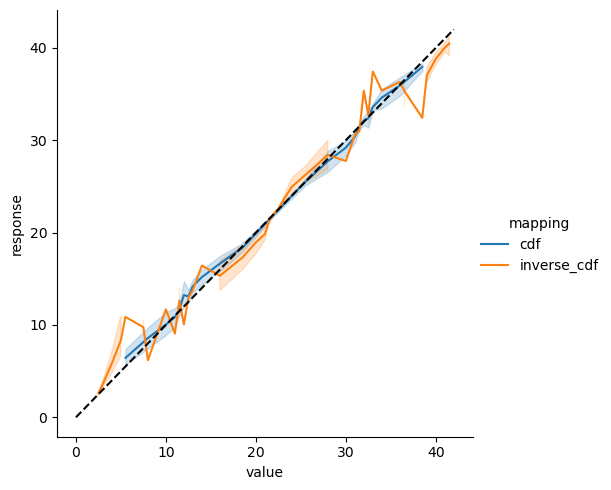

In [29]:
tmp = df.groupby(['subject', 'mapping', 'value'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='value', y='response', hue='mapping', kind='line')
plt.plot([0, 42], [0, 42], 'k--')

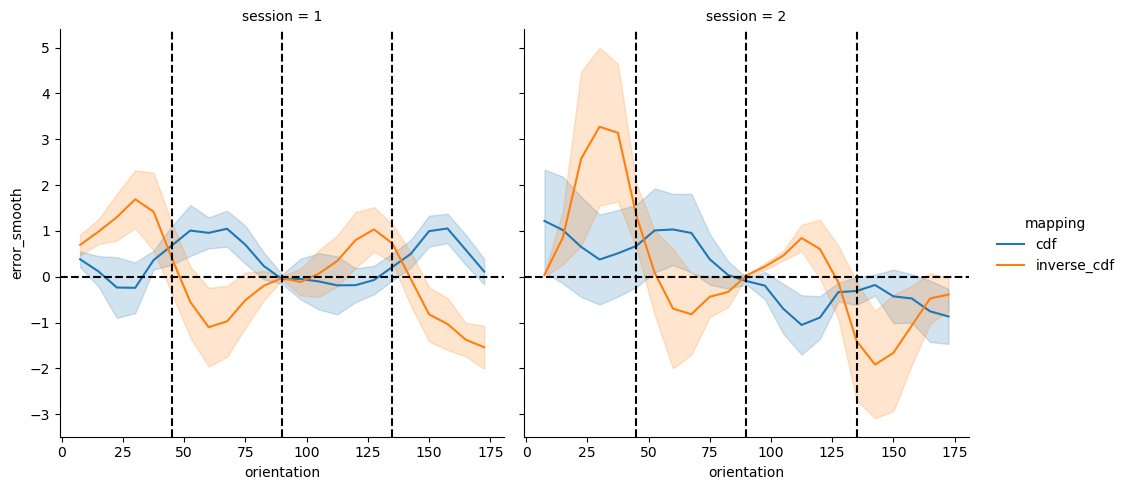

In [41]:
work = df.reset_index().copy()
work['error'] = work['response'] - work['value']

tmp = (
    work.groupby(['subject', 'mapping', 'orientation', 'session'], as_index=False)['error']
        .mean()
        .sort_values(['subject', 'mapping', 'orientation', 'session'])
)

tmp['error_smooth'] = (
    tmp.groupby(['subject', 'mapping'])['error']
       .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se', col='session')
g.map(plt.axhline, y=0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    g.map(plt.axvline, x=ori, color='k', linestyle='--')

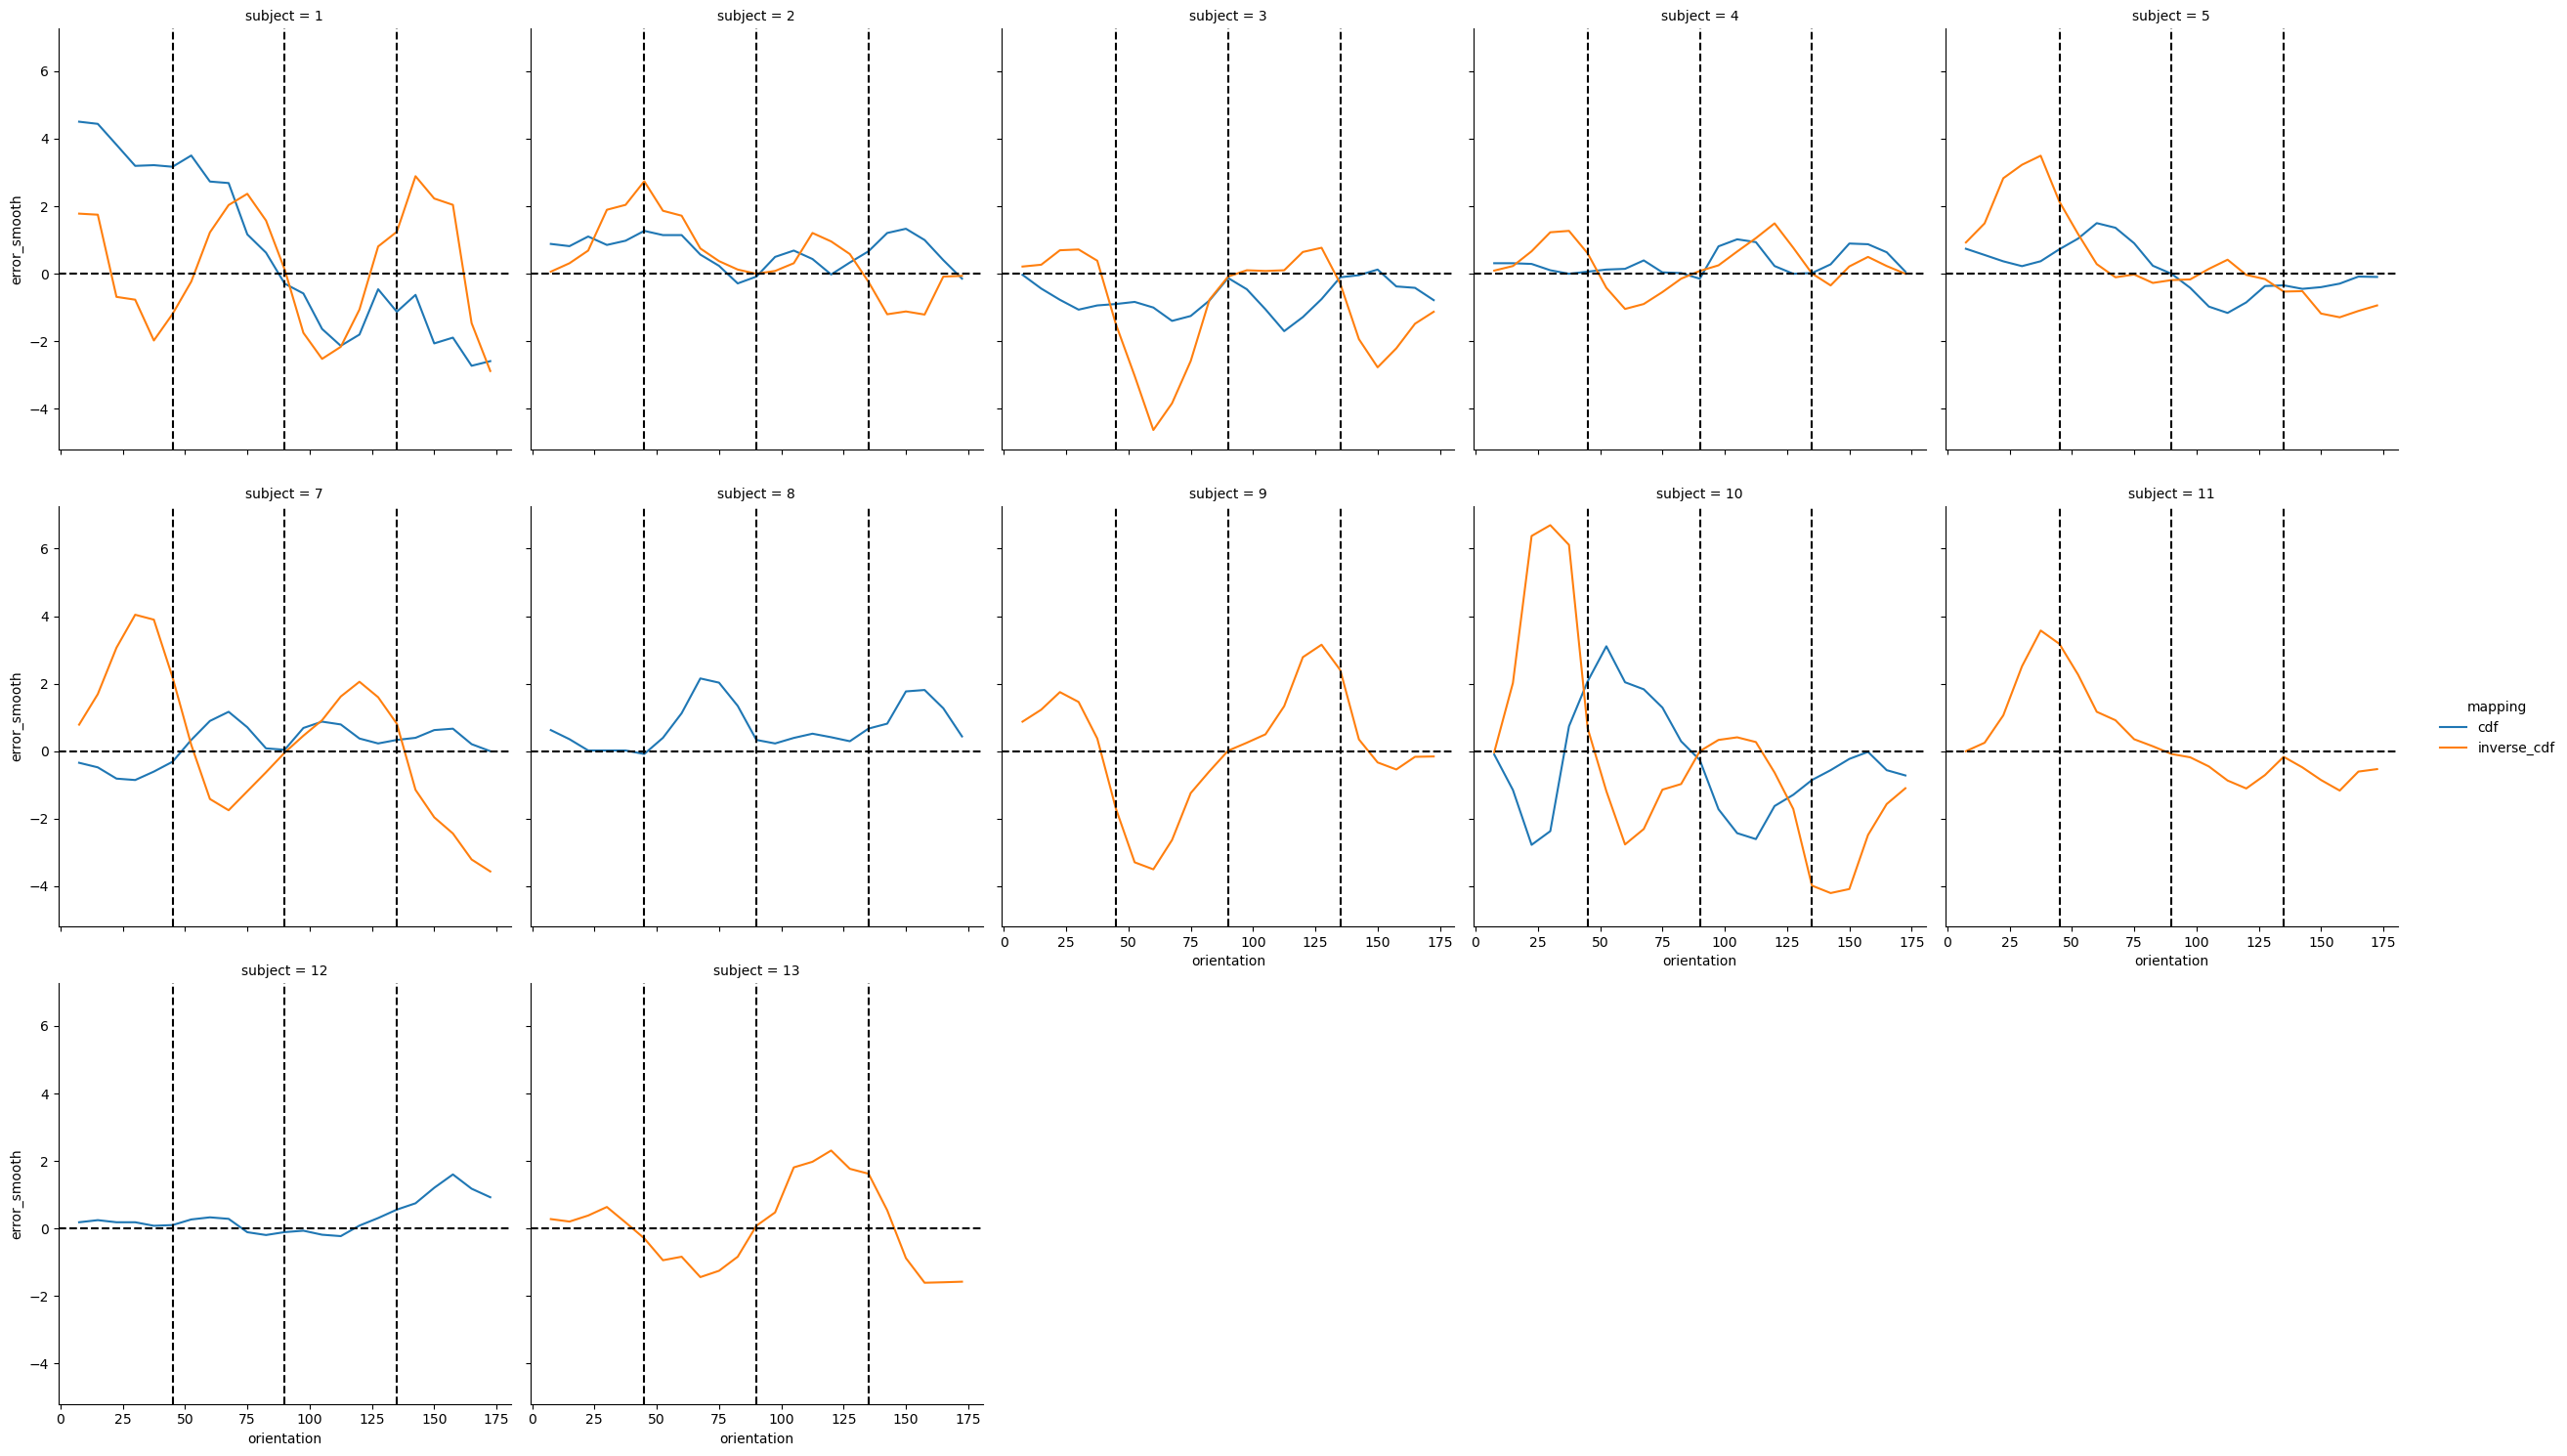

In [31]:
g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se',
                col='subject', col_wrap=5)
g.map(plt.axhline, y=0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    g.map(plt.axvline, x=ori, color='k', linestyle='--')

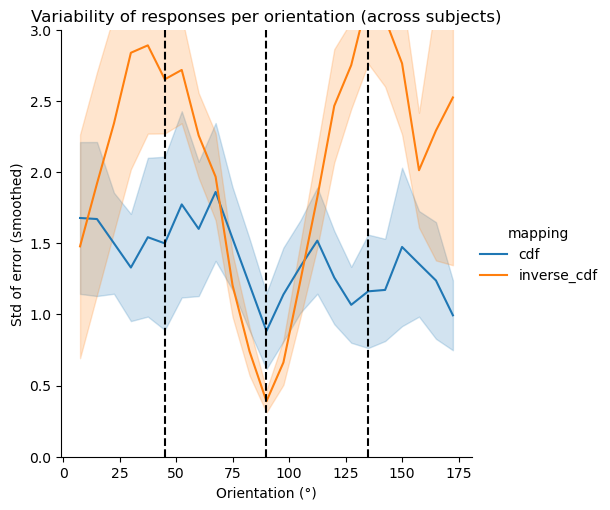

In [32]:
# Standard deviation of error per subject/mapping/orientation, smoothed over orientations
std_tmp = (
    work.groupby(['subject', 'mapping', 'orientation'], as_index=False)['error']
        .std()
        .rename(columns={'error': 'error_std'})
        .sort_values(['subject', 'mapping', 'orientation'])
)

std_tmp['error_std_smooth'] = (
    std_tmp.groupby(['subject', 'mapping'])['error_std']
           .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_smooth',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (smoothed)')
plt.title('Variability of responses per orientation (across subjects)')

for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

g.set(ylim=(0, 3))

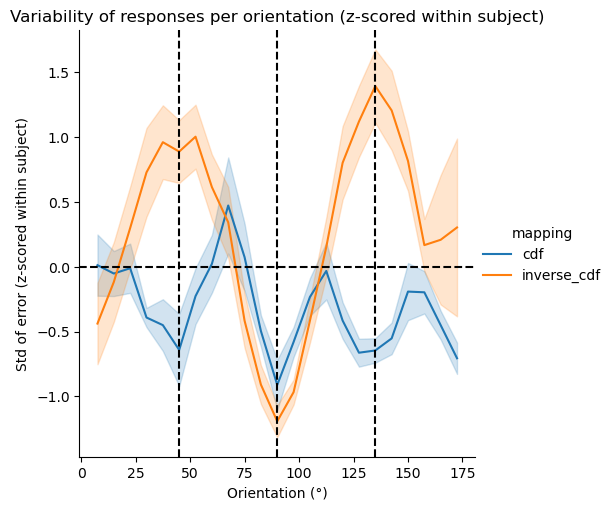

In [33]:
# Z-score error_std_smooth within each subject
std_tmp['error_std_z'] = (
    std_tmp.groupby('subject')['error_std_smooth']
           .transform(lambda s: (s - s.mean()) / s.std())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_z',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (z-scored within subject)')
plt.title('Variability of responses per orientation (z-scored within subject)')
plt.axhline(0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

In [34]:
rows = []
for subject_id in get_all_subject_ids():
    s = Subject(subject_id)
    try:
        d = s.get_behavioral_data().reset_index()
        d = d[d['event_type'] == 'feedback'].copy()
        d['response'] = pd.to_numeric(d['response'], errors='coerce')
        rows.append({
            'subject': subject_id,
            'n_rows': len(d),
            'n_response_nan': d['response'].isna().sum(),
            'mappings': sorted(d['mapping'].dropna().unique().tolist()),
            'runs_found': sorted(d['run'].dropna().unique().tolist()),
        })
    except Exception as e:
        rows.append({'subject': subject_id, 'error': str(e)})

pd.DataFrame(rows)

,subject,n_rows,n_response_nan,mappings,runs_found
0,1,368,17,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
1,10,368,17,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
2,11,184,3,[inverse_cdf],"[1, 2, 3, 4, 5, 6, 7, 8]"
3,12,184,6,[cdf],"[1, 2, 3, 4, 5, 6, 7, 8]"
4,13,184,4,[inverse_cdf],"[1, 2, 3, 4, 5, 6, 7, 8]"
5,2,368,8,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
6,3,368,5,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
7,4,368,6,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
8,5,368,17,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
9,7,368,4,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"


# Mean error per subject

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_49605/2680296933.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.catplot(data=tmp.to_frame("abs(error)"), x='mapping', y='abs(error)', kind='swarm', estimator=np.mean, ci=None)


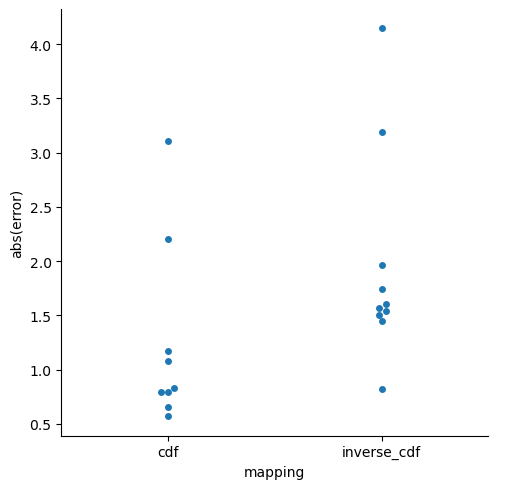

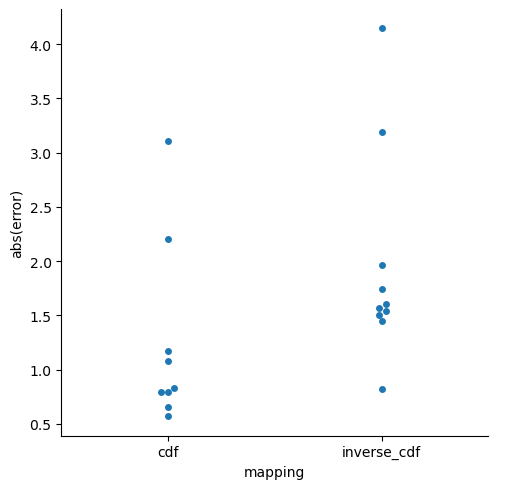

In [ ]:
df['error'] = df['response'] - df['value']
df['abs(error)'] = df['error'].abs()
tmp = df.groupby(['subject', 'mapping'])['abs(error)'].mean()

sns.catplot(data=tmp.to_frame("abs(error)"), x='mapping', y='abs(error)', kind='swarm')


In [23]:
tmp.groupby('mapping').agg(['mean', 'std'])

,mean,std
mapping,,
cdf,1.245841,0.849379
inverse_cdf,1.952905,0.974780


In [19]:
tmp

subject  mapping    
1        cdf            3.103448
         inverse_cdf    4.144068
2        cdf            1.084270
         inverse_cdf    1.538462
3        cdf            0.797814
         inverse_cdf    1.602778
4        cdf            0.571429
         inverse_cdf    0.822222
5        cdf            0.654494
         inverse_cdf    1.505780
7        cdf            0.831522
         inverse_cdf    1.966667
8        cdf            1.171271
9        inverse_cdf    1.570225
10       cdf            2.200565
         inverse_cdf    3.189655
11       inverse_cdf    1.444751
12       cdf            0.797753
13       inverse_cdf    1.744444
Name: abs(error), dtype: float64